# 线性回归

线性回归（Linear Regression）模型。最简单的机器学习模型。

本例采用最标准的方法：MSE（Mean Squared Error）方均根误差 + SGD（Stochastic Gradient Descent）随机梯度下降优化器实现

数据集使用定义的函数自己生成，自动引入正态分布误差。

### 定义一些基本的概念，注意与英文联合记忆
在机器学习的术语中，用于训练模型的数据称为*训练数据集*（training data set）
或*训练集*（training set）。
每行数据（比如一次房屋交易相对应的数据）称为*样本*（sample），
也可以称为*数据点*（data point）或*数据样本*（data instance）。


我们把试图预测的目标（比如预测房屋价格）称为*标签*（label）或*目标*（target）。
预测所依据的自变量（面积和房龄）称为*特征*（feature）或*协变量*（covariate）。


神经网络中任意两个节点中间的$w$
称为*权重*（weight），权重决定了每个特征对我们预测值的影响。


每层之间的$b$称为*偏置*（bias）、*偏移量*（offset）或*截距*（intercept），一般每层统一为一个值。
偏置是指当所有特征都取值为0时，预测值应该为多少。

### 模型作用

简单用直线（超平面）拟合数据，重点在于**拟合**，模型输出是**连续的**表达式（函数）。

可以用于找规律、预测、已知表达式求参数等等。

## 代码实现

首先导入相关库，第一句是让plot绘制的图片内联到jupyter中显示

In [ ]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

# 解决绘图导致内核崩溃
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

### 1. 生成数据集。features为数据中的X，labels为数据中的y

In [2]:
# 传入权值向量 w ，偏移量 b，产生样本的个数
# 返回数据集X, y
def synthetic_data(w, b, num_examples):
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape);
    return X, y.reshape((-1, 1)) # 将 y 转为列向量返回

In [3]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

features[0], labels[0]

(tensor([-0.6373, -0.0232]), tensor([3.0076]))

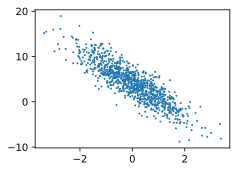

In [ ]:
d2l.set_figsize()
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1)

### 2. 读取数据集。每次随机抽取一批样本。

In [5]:
# 输入批量大小，数据集（样本）
# 返回一个迭代器：即执行到yield后返回一次，下次调用从yield语句开始运行
# 这个迭代器的内容是一个批量的数据集
def data_iter(batch_size, features, labels):
    # 对整个数据集创建索引
    num_examples = len(features)
    indicies = list(range(num_examples))
    
    random.shuffle(indicies)
    for i in range(0, num_examples, batch_size):
        # 生成索引列表，用切分的方法
        batch_indicies = torch.tensor(indicies[i: min(i + batch_size, num_examples)])
        yield features[batch_indicies], labels[batch_indicies]

In [ ]:
batch_size = 10

# 打印一个小样本，查看yield返回的情况
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.6618,  0.7372],
        [ 1.3908, -1.4580],
        [ 0.1365, -0.9439],
        [-1.7096,  0.2060],
        [ 0.8053, -0.5786],
        [-1.7067,  0.3105],
        [-1.1272, -1.5944],
        [-1.5546, -0.1327],
        [-0.9792, -0.7611],
        [ 2.0543, -1.2096]]) 
 tensor([[ 3.0164],
        [11.9312],
        [ 7.6961],
        [ 0.0988],
        [ 7.7645],
        [-0.2605],
        [ 7.3593],
        [ 1.5237],
        [ 4.8210],
        [12.4284]])


### 3. 初始化模型参数

In [7]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

### 4. 定义模型

In [8]:
# 计算输出，返回结果，是向量
def linreg(X, w, b):
    """"线性回归模型"""
    return torch.matmul(X, w) + b

# 平方损失，返回的是向量
def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

# 小批量梯度下降，即随机梯度下降
def sgd(params, lr, batch_size):
    with torch.no_grad():   # 解绑梯度计算：这里不需要记录计算的结果
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

### 5. 训练

In [9]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)   # 计算损失函数
        l.sum().backward()  # 计算梯度（自动求导）
        sgd([w, b], lr, batch_size) # 更新参数
        
    # 每个训练epoch结束，输出模型在整个数据集上的结果
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.031301
epoch 2, loss 0.000117
epoch 3, loss 0.000054


In [10]:
# 展示模型的估计误差
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([-1.5950e-04,  7.6771e-05], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0005], grad_fn=<RsubBackward1>)
